In [2]:
import base64
import io
import os
import json
import pandas as pd
from PIL import Image
from mistralai import Mistral
from ultralytics import YOLO

# Einleitung

## Vorhaben

Dieses Jupyter Notebook soll aufzeigen, wie mittels einer Objekterkennung inhaltliche Textregionen eines Findmittels erkannt und so an eine OCR übergeben werden, dass die Ergebnisse der Texterkennung in der Struktur des Findmittels verortet und einem Feld zugewiesen werden können.

## Ausgangslage

Grundlage ist das Findmittel des Postkartenherstellers [Verlag Gebrüder Metz](https://de.wikipedia.org/wiki/Gebr%C3%BCder_Metz). Das [Haus der Geschichte Baden-Württemberg](https://www.hdgbw.de/landesgeschichtliche-sammlung/bildarchiv/#gebrueder-metz) besitzt das Firmenarchiv dieses Verlags. Der Bestand besteht u. a. aus ca. 200.000 bis 270.000 Glasplatten. Erschlossen ist der Bestand durch zwei firmeneigene Findmittel: die Plattenbücher - handschriftliche Invetarbücher zu den Fotoaufnahmen - und die sogenannten Blaumappen, die auch digitalisiert vorliegen.

<img src="./imgs_publication/Blaumappe_Meersburg.jpg" alt="Bild einer Seite aus der Blaumappe" width="600"/>
<br><i>Beispielseite aus einer Blaumappe</i>

Die Mappen wurden in den 1990ern auf Mikofiche fotografiert, und diese 2023 digitalisiert.

![Beispiel eines Scans](./imgs_publication/Blaumappe_Digitalisiert.png)  
*Digitalisat der Doppelseite einer Blaumappe von einem Mikrofiche*

Insgesamt liegen 1.762 Blaumappen digitalisiert vor, mit jeweils zw. 15 und 30 gescannten Doppelseiten. Nicht alle Seiten enthalten Bilder, auch existieren verschiedene Formular-Layouts (s. u.), so dass auch die Anzahl der enthaltenen Bilder pro Scan schwanken kann. Sehr grob geschätzt könnten aber um die 200.000 Motive durch die Blaumappen dokumentiert sein.

### Literatur zur Sammlung Metz

Büchner, Dieter: Ein Denkmal? Viele Denkmale! Das Archiv der Tübinger Postkartenfirma Metz, in: Denkmalpflege in Baden-Württtemberg 2 (2003), S. 187 f.  
Kirchberger, Stefan: Plattenbücher und Blaumappen. Das Metz-Archiv im Haus der Geschichte Baden-Württemberg, in: Das Archiv 4 (2007), S. 74-78.  
Ders: Geschichtsbilder – Das Bildarchiv im Haus der Geschichte Baden-Württemberg, in: Rundbrief Fotografie 21 (2014), 1–2, S. 48–55.  
Krause, Albrecht: Die Sammlung Metz, in: Zu schön, um wahr zu sein. Photographien aus der Sammlung Metz, hg. v. Haus der Geschichte Baden-Württemberg, Stuttgart 1997, S. 17-38.  

## Projektziel

Ziel der KI-gestützten Erschließung ist eine strukturierte Zusammenstellung von Bildmotiv, Bildnummer, Ort, Bildtitel, Datierung und Bildmappennummer.  
Diese Objekterkennung soll die OCR vorbereiten und künftig eine direkte Recherche nach der Bildnummern zu bestimmten Orten ermöglichen.
Idealerweise ermöglicht dies auch den Import der Metadaten und ggf. auch der Blaumappen-Motive in die Sammlungsdatenbank.

![Bild mit Hervorhebungen zu den gewünschten Informationen](./imgs_publication/Blaumappe_Annotationen.png)  
*Beispiel der Angaben zu einem Bild; Grün: gesamter Eintrag, Lila: Foto, Blau: Bildnummer, Rot: Titel, Türkis: Datierung*

Da das Formular-Layout in den Fotomappen variiert und die damaligen Bearbeiter:innen gelegentlich bei ihren Eintragungen von der Vorlage abwichen, soll das Objekterkennungs-Modell [YOLOv8n](https://docs.ultralytics.com/de/models/yolov8/) darauf trainiert werden, die gesuchten Informationen auf den Scans zu klassifizieren, bevor sie an eine OCR weitergeleitet werden.

![Variante des Vordrucks](./imgs_publication/Blaumappen_Layout-Alternative_2.png)
![Variante des Vordrucks](./imgs_publication/Blaumappen_Layout-Alternative.png)  
*Weitere Varianten des Formulars*


## Bisherige Vorarbeiten

Zum Training des Modells würden 170 Scans in CVAT annotiert. Die einzelnen Boxklassen waren:
- *Bild-Text*: Umfasst den gesamten Eintrag zu einem Foto
- *Bild*: Nur das Foto im Eintrag
- *Bildnummer*: Die Nummer des Glassplattennegativs im Archiv 
- *Titel*: Die Bezeichnung der Aufnahme im Eintrag
- *Datierung*: Die Datierung der Aufnahme im Eintrag
- *Ortsbezeichnung*: Ortsbezeichnungen, die im Inhaltsverzeichnis der Mappen oder als Überschrift auf den Bildseiten vorkommen. Ortsnamen im Bildtitel wurden nicht zusätzlich als Ortsbezeichnung gelabelt.
- *Ortsbuchstabe*: Kennzeichnet die i. d. R. an den oberen Seitenecken notierten Buchstaben, mit denen Orte innerhalb einer Mappe im Inhaltsverzeichnis der Mappe referiert werden. Im Inhaltsverzeichnis wird das Label nicht  verwendet.

Anschließend wurde das annotierte Material im Verhältnis 9:1 in ein Trainings- und ein Validierungsset aufgeteilt, wobei auf die Anwesenheit von selten vertretenen Klassen in beiden Sets geachtet wurde. 

Das Training des YOLOv8n-Modells mit 100 Epochen auf einem Microsoft Surface mit 12th Gen Intel Core i5-1235U dauerte ca. 217 min, und war mit Abstrichen bei im Trainingsset sehr seltenen Klassen *Ortsbezeichnung* und *Ortsbuchstabe* sehr erfolgreich.

<img src="./imgs_publication/results.png" alt="Trainingsmetriken im Verlauf der Epochen" width="800"/>
<br><i>Validierung der Modellperformance nach jeder Trainingsepoche</i>
<br><br>
<img src="./imgs_publication/confusion_matrix_normalized.png" alt="Confusion-Matrix für die Boxklassen" width="600"/>
<br><i>Die Confusion-Matrix</i>

## Vorliegendes Proof-of-Concept

Mit dem Proof-of-Concept soll gezeigt werden, dass 

- das Modell erfolgreich die relevanten Bereiche in einem für das Modell unbekannten Bild erkennt, 
- die in der Objekterkennung erhaltenen Bildbereiche an eine OCR übergeben werden können, 
- die Informationen zu den einzelnen Einträgen gruppiert werden können, 
- und am Ende eine strukturierte Ablage erzeugt werden kann.

Die strukturierte Ablage soll in diesem PoC zu jeden Bildeintrag auf dem Scan angeben: 

- Die Quelldatei 
- ein Bildausschnitt zum Blaumappeneintrag inkl. Bild und Bildinformationen 
- die OCR-Ergebnisse zu den Feldern Bildnummer, Titel und Datierung

Als OCR wird vorerst die Mistral OCR-API verwendet.



# Proof of Concept

## Layouterkennung

Laden der Bilddatei

In [1]:
PATH_TO_IMAGE = "1470-0002.jpg"

Laden des trainierten Modells

In [3]:
PATH_TO_MODEL = "best.pt"

In [4]:
trained_model = YOLO(PATH_TO_MODEL)

Durchführen der Objekterkennung

In [5]:
results = trained_model.predict(
    PATH_TO_IMAGE,
#    visualize=True,
    save=True,
    project="proof-of-concept-results",
    save_txt=True,
    show=True,
    save_crop=True,
)


image 1/1 c:\Users\werner\02_proof-of-concept\1470-0002.jpg: 512x800 16 Bildnummers, 17 Titels, 16 Datierungs, 16 Bilds, 16 Bild-Texts, 169.5ms
Speed: 8.2ms preprocess, 169.5ms inference, 21.2ms postprocess per image at shape (1, 3, 512, 800)
Results saved to C:\Users\werner\02_proof-of-concept\proof-of-concept-results\predict4
1 label saved to C:\Users\werner\02_proof-of-concept\proof-of-concept-results\predict4\labels


### Bericht: erkannte Labels pro Datei

In [6]:
for result in results:
    print(f"Für {result.path.split("\\")[-1]}:\n") # Ausagbe Dateinamen
    # TODO: os.path.basename(result.path) verwenden, um Dateinamen zu extrahieren

    count_cls_dict = dict()  # Dict zum Sammeln der Häufigkeiten pro Klasse

    # Häufigkeit jeder Klasse in cls-Attribute von Boxes im Dictionary speichern
    for cls in result.names:
        count_cls_dict[cls] = list(result.boxes.cls).count(cls)

    # Nummern der Klassen durch Klassenlabels in Dictionary ersetzen
    for cls in result.names:
        class_label = result.names[cls]
        count_cls_dict[class_label] = count_cls_dict.pop(cls)

    # Ausgabe der Anzahl pro Klasse
    for class_label, count in count_cls_dict.items():
        print(f"\t{class_label}: {count}")


Für 1470-0002.jpg:

	Bildnummer: 16
	Titel: 17
	Datierung: 16
	Bild: 16
	Ortsbezeichnung: 0
	Bild-Text: 16
	Ortsbuchstabe: 0


## Nachbearbeitung

### Konvertierung

DataFrame für Bildpfad, Klasse, Confidence, Koordinaten xywh, xywhn, xyxy, xyxyn

In [7]:
boxes_df = pd.DataFrame(columns=["filepath", "cls", "confidence", "xywh", "xywhn", "xyxy", "xyxyn"])

Auslesen der Werte der Objekterkennung in das DataFrame

In [8]:
for result in results:
    for box in result.boxes:
        record = ["", box.cls.item(), box.conf.item(), box.xywh[0], box.xywhn[0], box.xyxy[0], box.xyxyn[0]]
        boxes_df.loc[len(boxes_df)] = record
    
    # Klassifizierungs-IDs durch Klassen-Titel ersetzen
    box_names_dict = result.names
    boxes_df["cls"] = boxes_df["cls"].map(box_names_dict)

    # Pfad zur Bilddatei
    filepath = result.path
    boxes_df["filepath"] = filepath
    

### Gruppierung

Spalte für Group-ID erstellen und jedem Bild-Text eine ID zuweisen.

In [9]:
def initiate_groups(df):
    """
    Ergänzt die Spalte group_id nach Spalte filepath. Datensätze zu Bild-Text-Labels erhalten eindeutige group_ids.
    """

    df.loc[df["cls"] == "Bild-Text", "group_id"] = list(range(len(boxes_df[boxes_df.cls == "Bild-Text"])))
 
    df = df[['filepath', 'group_id', 'cls', 'confidence', 'xywh', 'xywhn', 'xyxy', 'xyxyn']]

    return df

**Verbessern**: Gruppennummern von links oben nach rechts unten vergeben:  
-> Bild-Text-Boxes sortieren nach x1, y1

**TODO:** Gruppieren anhand der absoulten (xyxy, xywh) wie relativen Koordianten (xyxyn, xywhn)  
**TODO:** confidence-Schwellert: Boxen ab bestimmten confidence-Wert übernehmen

In [10]:
boxes_df = initiate_groups(boxes_df)

Gruppieren der restlichen Labels: Alle Lables, deren Box-Mittelpunkt (x- und y-Werte aus xywh) innerhalb einer Bild-Text-Box liegen (xyxy) erhalten dessen Group-ID

In [11]:
for i in boxes_df[boxes_df.cls == "Bild-Text"].index:

    # Koordianten der Eckpunkte von Bild-Text
    x1 = float(boxes_df.xyxy[i][0])
    y1 = float(boxes_df.xyxy[i][1])
    x2 = float(boxes_df.xyxy[i][2])
    y2 = float(boxes_df.xyxy[i][3])
    
    # Group_id des Bild-Texts 
    box_group_id = boxes_df.group_id[i].item()

    # Setze die Group-Id bei allen nicht-Bild-Text-Labels, deren Box-Mittelpunkte innerhalb der Koordinaten des Bild-Text liegen,
    # auf die der Bild-Text-Box
    boxes_df.loc[
        (boxes_df.cls != "Bild-Text") 
        & (boxes_df.xywh.str[0].astype(float) > x1 ) 
        & (boxes_df.xywh.str[0].astype(float) < x2 ) 
        & (boxes_df.xywh.str[1].astype(float) > y1 ) 
        & (boxes_df.xywh.str[1].astype(float) < y2 ),
        "group_id"]  = box_group_id

### Bericht: Gruppierung

Übersicht über die Anzahl der Boxen pro Gruppe und Label:

In [12]:
# Übersicht über die Anzahl der Boxen pro Gruppe und Label
print(boxes_df.pivot_table(index=["filepath", "group_id"], columns="cls", aggfunc="size", fill_value=0).to_string())

cls                                                         Bild  Bild-Text  Bildnummer  Datierung  Titel
filepath                                          group_id                                               
c:\Users\werner\02_proof-of-concept\1470-0002.jpg 0.0          1          1           1          1      2
                                                  1.0          1          1           1          1      1
                                                  2.0          1          1           1          1      1
                                                  3.0          1          1           1          1      1
                                                  4.0          1          1           1          1      1
                                                  5.0          1          1           1          1      1
                                                  6.0          1          1           1          1      1
                                              

Anzahl der Boxen, die keiner Gruppe zugeordnet werden konnten, pro Label:

In [13]:
if boxes_df["group_id"].isna().sum() > 0:
    print(boxes_df.loc[boxes_df["group_id"].isna(), "cls"].value_counts().to_string())
else:
    print("Alle Boxen konnten einer Gruppe zugeordnet werden.")

Alle Boxen konnten einer Gruppe zugeordnet werden.


## OCR

Mistral-Client einrichten

In [14]:
MISTRAL_API_KEY = os.getenv("wer_mistral_api_key")

In [15]:
mistral_client = Mistral(api_key=MISTRAL_API_KEY,  timeout_ms=300000)

Bild für Bildausschnitte laden

In [16]:
image = Image.open(PATH_TO_IMAGE)

Bildausschnitte auf DataFrame an Mistral schicken

In [17]:
for i in boxes_df.loc[(boxes_df["cls"] != "Bild-Text") & (boxes_df["cls"] != "Bild")].index:

    # Koordinaten des Bildausschnitts
    x1, y1, x2, y2 = map(float, boxes_df.loc[i].xyxy)

    # Bildausschnitt mit PIL
    cropped_image = image.crop((x1, y1, x2, y2))

    # Bildausschnitt in base64 konvertieren:

    buffered = io.BytesIO()
    cropped_image.save(buffered, format="JPEG")

    img_bytes = buffered.getvalue()
    
    img_base64 = base64.b64encode(img_bytes).decode('utf-8')
    
    # Senden an Mistral

    mistral_ocr_response = mistral_client.ocr.process(
        model="mistral-ocr-latest",
        document={
            "type": "image_url",
            "image_url": f"data:image/jpeg;base64,{img_base64}"
        },
        include_image_base64=True
    )

    # Mistral-Response in Json umwandeln
    mistral_ocr_response_json = json.loads(mistral_ocr_response.model_dump_json())

    # Text der Mistral-Response extrahieren und in DataFrame speichern
    ocr_text = mistral_ocr_response_json["pages"][0]["markdown"]

    boxes_df.loc[i, "ocr_text"] = ocr_text

## Ausgabe

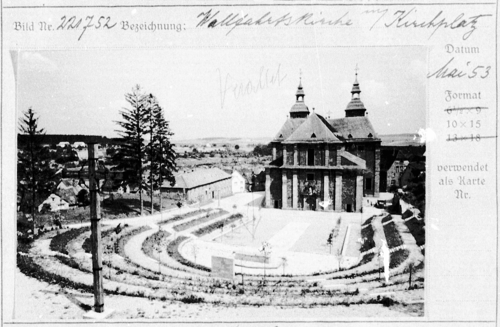

    group_id         cls                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

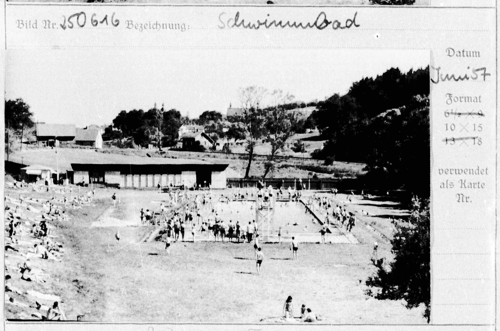

    group_id         cls                                      ocr_text
33       1.0       Titel                       Bezeichnung: Schwimmbad
34       1.0   Datierung                                Datum\nJuni 57
70       1.0  Bildnummer  1000\n250616 B\n250617 B\n250618 B\n250619 B





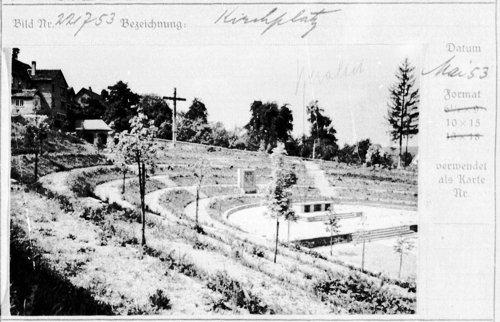

    group_id         cls                                                                                                                                                                                                                                         ocr_text
42       2.0   Datierung                                                                                                                                                                                                                                   Datum\nMai '53
44       2.0  Bildnummer  ID-101253\n801253 An example of the use of the 2002-2003 European Union and the European Union is to be used in the 2003 European Union. 801254 An example of the use of the 2002-2003 European Union is to be used in the 2003 European Union.
71       2.0       Titel                                                                                                                                                                                  

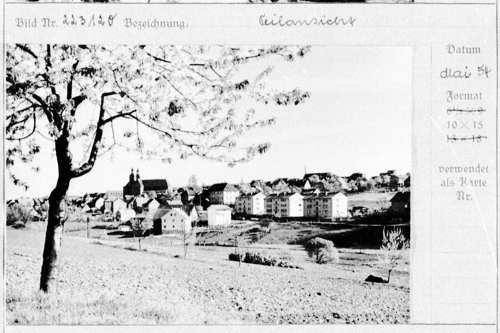

    group_id         cls                  ocr_text
54       3.0       Titel  Bezeichnung: Teilansicht
55       3.0   Datierung           Datum\ndlaiv 54
60       3.0  Bildnummer         B\nBld Nr. 223/20





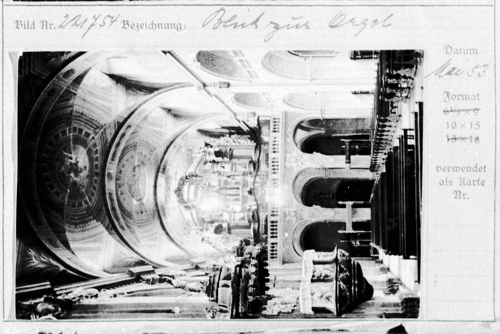

    group_id         cls                                                                                                                                                                                                                                                 ocr_text
45       4.0   Datierung  100\n\nDate 18 Dec 53\n\n|  No. | Name | Purpose  |\n| --- | --- | --- |\n|  1 | B. R. B. H. B. B. | 1st Lt. 18th Inf.  |\n|  2 | B. R. B. H. B. | 2nd Lt. 18th Inf.  |\n|  3 | B. R. B. H. B. | 3rd Lt. 18th Inf.  |\n\nReturned to A. G. O. 18 Dec 53
61       4.0       Titel                                                                                                                                                                                                Bezeichnung: Blick zur Orgel\n\n![img-0.jpeg](img-0.jpeg)
69       4.0  Bildnummer                                                                                                                                                          

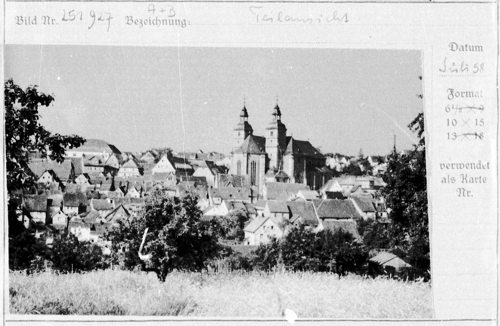

    group_id         cls                       ocr_text
48       5.0   Datierung                 Datum\nJuli 58
53       5.0  Bildnummer                 Bld Mr. 257927
73       5.0       Titel  A+B\nBezeichnung: Terlanisich





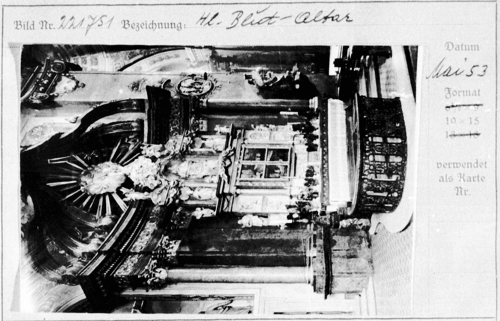

    group_id         cls                                                      ocr_text
38       6.0  Bildnummer                                               Bild Nr. 221751
52       6.0   Datierung                                          100\n\nDatum\nMai 53
56       6.0       Titel  Bezeichnung: Hl-Blüt-Alfar\n\n100000000000000000000000000000





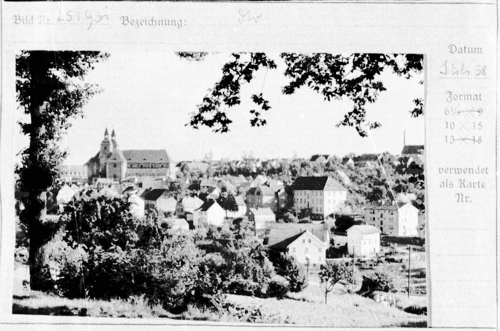

    group_id         cls                                                                                                                                                                                                                                                ocr_text
36       7.0   Datierung                                                                                                                                                                                                                                          Datum\nJuli 58
58       7.0  Bildnummer  ID-10192\n16192 A group of people is the group of people who are in the group of people. 16193 A group of people is the group of people who are in the group of people. 16194 A group of people is the group of people who are in the group of people.
76       7.0       Titel                                                                                                                                                             

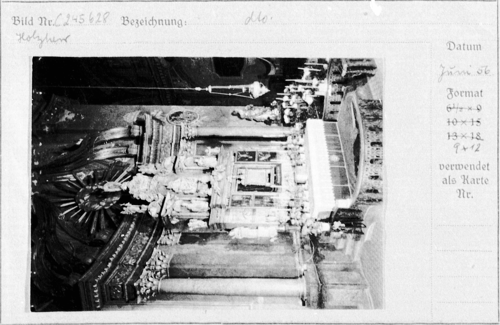

    group_id         cls                      ocr_text
57       8.0   Datierung              Datum\n\nJuni 56
68       8.0  Bildnummer  B\nBld Nr. C 245 628\nHohdun
75       8.0       Titel             Bezeichnung: dto.





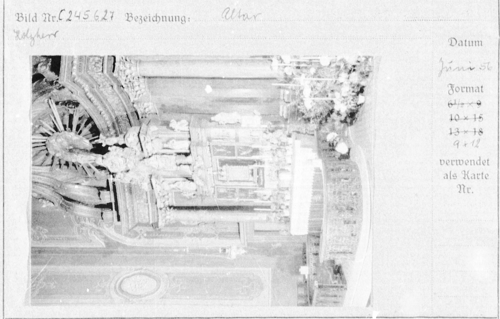

    group_id         cls                    ocr_text
65       9.0  Bildnummer  B\nBld Mr. C245627\n4d.106
66       9.0   Datierung              Datum\nJuni 56
77       9.0       Titel          Bezeichnung: Altar





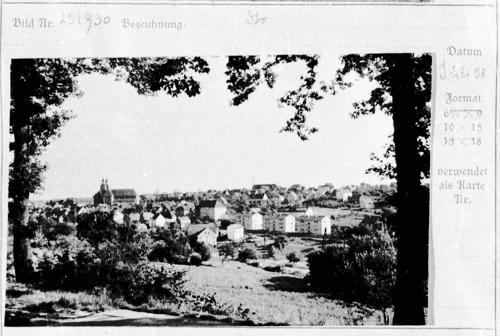

    group_id         cls                          ocr_text
49      10.0   Datierung                    Datum\nJuli 58
59      10.0  Bildnummer  ID-10102\n651930 Bidd No. 251930
62      10.0       Titel                  Bezeichnung: G10





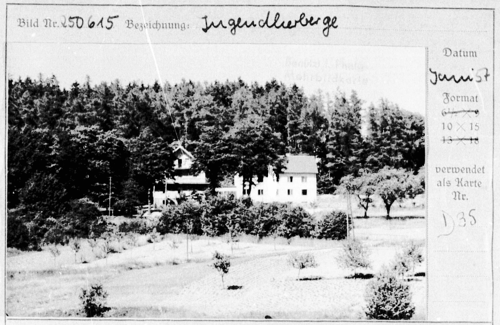

    group_id         cls                                                                                       ocr_text
40      11.0   Datierung                                                                                 Datum\nJuni 57
50      11.0       Titel                                                                  Bezeichnung: Ingen Allerberge
64      11.0  Bildnummer  ID-10122\n650614 He was born in 1964. 650615 He was born in 1965. 650616 He was born in 1966.





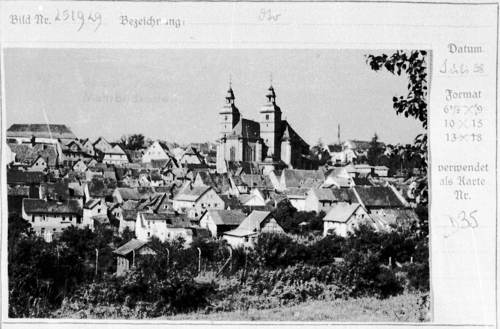

    group_id         cls            ocr_text
32      12.0  Bildnummer        Bldg. 251929
43      12.0   Datierung  # Datum\n\nJuli 58
80      12.0       Titel        Bezeichnung:





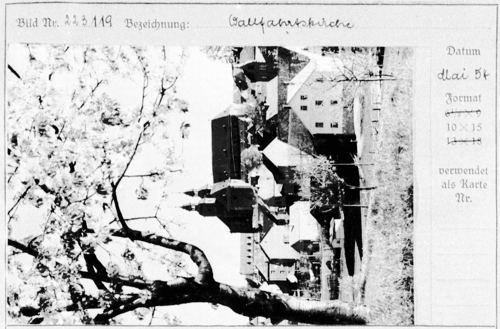

    group_id         cls                       ocr_text
51      13.0  Bildnummer                  Bldn. 223.119
63      13.0       Titel  Bezeichnung: Gallfahrtskirche
67      13.0   Datierung                 Datum\ndlaï 54





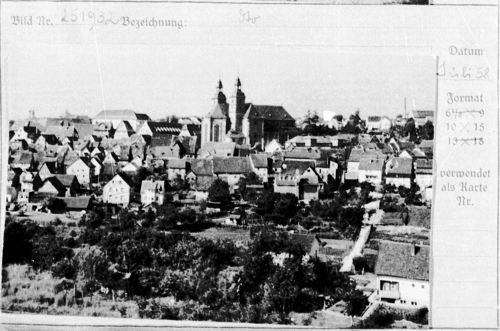

    group_id         cls                                                                                                                                                                                                                                                                                                                                                                                                                                                                               ocr_text
46      14.0   Datierung                                                                                                                                                                                                                                                                                                                                                                                                                                                                       Datum\n3 juli 58
72      

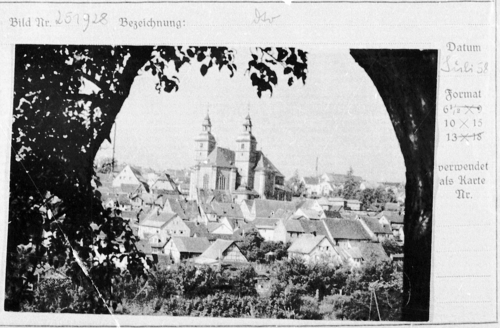

    group_id         cls                                                                                                                                                                                                                                                                                                                                                                                                            ocr_text
35      15.0   Datierung                                                                                                                                                                                                                                                                                                                                                                                                     Datum\nSieli 58
41      15.0  Bildnummer  ID-101222\n851928 Biedrich, J. (1999). The American Indian. 851929 Biedrich, J. (1999). The American Indian. 851930 

In [18]:
for i in boxes_df.loc[boxes_df["cls"] == "Bild-Text"].index:

    group_id = boxes_df.group_id[i]

    x1, y1, x2, y2 = map(float, boxes_df.loc[i].xyxy)

    # Bildausschnitt mit PIL
    cropped_image = image.crop((x1, y1, x2, y2))

    # Bildausschnitt verkleinern
    w, h = cropped_image.size
    new_w = 500
    new_h = int(h * (new_w / w))
    cropped_image = cropped_image.resize((new_w, new_h))

    display(cropped_image)

    # Sichern des Bildausschnitts
    cropped_image.save(f"./groups_images/cropped_image_group_{int(group_id)}.jpg")

    print(boxes_df.loc[
        (boxes_df["group_id"] == group_id)
        & (
            (boxes_df["cls"] == "Titel")
            | (boxes_df["cls"] == "Datierung")
            | (boxes_df["cls"] == "Bildnummer")
        ), ["group_id", "cls", "ocr_text"]].to_string())
    
    print("\n\n")


Sichern der Ergbenisse in einer CSV

In [19]:
boxes_df.to_csv("./proof-of-concept_final-results.csv", index=False)

# Fazit

Das Modell erkannte im ihm unbekannten Bild mit hoher Zuverlässigkeit die relevanten Regions of Interest.

Die einzelnen Informationen konnten zu ihren Einträgen zugeordnet werden.

Es konnten die einzelnen Informationen gezielt als Bildausschnitte an die Texerkennung gesendet und die Ergebnisse wieder dem Eintrag in der richtigen Kategorie zudeordnet werden.

Eine grundlegende struktrierte Ablage erfolgte als csv.

Die Übergabe der Bilder an Mistral ohne Prompt führte in einigen Fällen zu starken Halluzinationen.